<a href="https://colab.research.google.com/github/misge8-del/Customer-Churn-XGBoost/blob/main/Customer_Churn_Prediction_(Telecom_Sector).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📉 Customer Churn Prediction Using XGBoost
**Author:** ***Misgina Gebregergs***  
**Framework:** XGBoost with Stratified K-Fold Cross-Validation & GridSearchCV

### 📌 Project Objective
This project implements an end-to-end Machine Learning pipeline for predicting customer churn in the telecom sector.



### ⚙️ Phase 1: Environment Initialization & Library Imports
In this section, we instantiate our system dependencies. We leverage `xgboost` for our gradient boosting classifier, `scikit-learn` for tracking validation metrics, and `joblib` for persisting the finalized model binary.

In [82]:
!pip install xgboost -q

## Step 1: Import Required Libraries

Import the libraries needed for data processing, preprocessing, modeling, evaluation, and saving the model.

In [83]:
# Import warnings to manage warning messages
import warnings

# Ignore warning messages to keep the output clean
warnings.filterwarnings("ignore")

# Import Pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Import tools for data splitting, cross-validation, and hyperparameter tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# Import tools for scaling numerical features and encoding categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import ColumnTransformer for applying different preprocessing to different columns
from sklearn.compose import ColumnTransformer

# Import Pipeline for combining preprocessing and model steps
from sklearn.pipeline import Pipeline

# Import SimpleImputer for handling missing values
from sklearn.impute import SimpleImputer

# Import tools for plotting ROC and Precision-Recall curves and calculating AUC
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Import Logistic Regression classification model
from sklearn.linear_model import LogisticRegression

# Import XGBoost classification model
from xgboost import XGBClassifier


# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,        # Measures overall prediction accuracy
    precision_score,       # Measures how many positive predictions are correct
    recall_score,          # Measures how many actual positives are detected
    f1_score,              # Combines precision and recall
    roc_auc_score,         # Measures the model's ability to distinguish classes
    confusion_matrix,      # Shows correct and incorrect predictions by class
    classification_report  # Provides a summary of classification metrics
)

# Import Joblib for saving and loading trained ML models
import joblib

print("✅ All core industry libraries successfully imported and initialized.")


✅ All core industry libraries successfully imported and initialized.


## Step 2: Load the Dataset

Load the telecom customer churn dataset and inspect the first few rows.

In [84]:
# Load The Dataset

from google.colab import drive
drive.mount("/content/drive")

import os
os.listdir("/content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['.config',
 '.ipynb_checkpoints',
 'Telecom-Sector-Customer-Churn (1).csv',
 'churn_xgboost_model.joblib',
 'drive',
 'sample_data']

In [85]:
data=pd.read_csv("/content/Telecom-Sector-Customer-Churn (1).csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Explore the Dataset

Inspect the columns, data types, and missing values.

In [86]:
print(data.columns)
print(data.dtypes)
print(data.isnull().sum())

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID       

## Step 4: Data Cleaning

Remove the customer ID, convert `TotalCharges` to numeric, and encode the target variable.

In [87]:
# Remove customerID (not useful for prediction)
data = data.drop("customerID", axis=1)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Encode target variable
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(data["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## Step 5: Exploratory Data Analysis

Examine the distribution of customers who churned and those who stayed.

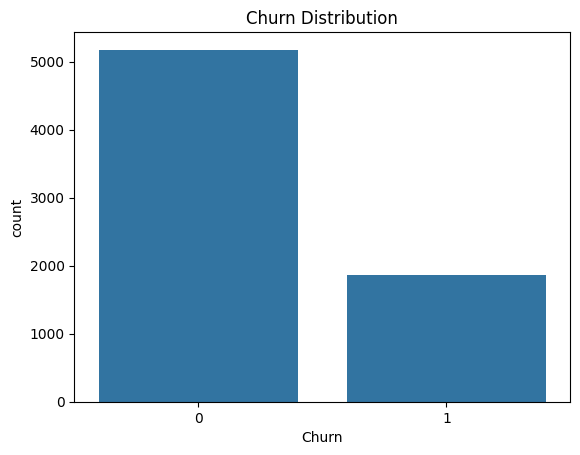

In [88]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

## Step 6: Feature Engineering

Create additional features that may help the model identify customer churn patterns.

In [89]:
# Monthly value ratio
data["ValueRatio"] = (
    data["TotalCharges"] /
    (data["tenure"] + 1)
)

# Tenure group
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New", "Short", "Medium", "Long"]
)

## Step 7: Define Features and Target

Separate the input features from the target variable.

In [90]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

## Step 8: Split the Data

Split the dataset into training and testing sets while preserving the churn class distribution.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 9: Build the Preprocessing Pipeline

Impute missing values and encode categorical features before training the models.

In [92]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Step 10: Train Logistic Regression Baseline

Train a simple baseline model to provide a reference for evaluating XGBoost.

In [93]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ValueRatio'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [94]:
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("-------------------")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression
-------------------
Accuracy: 0.8041163946061036
Precision: 0.6666666666666666
Recall: 0.5240641711229946
F1: 0.5868263473053892
ROC AUC: 0.8466403162055336

Confusion Matrix:
[[937  98]
 [178 196]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## Step 11: Train the XGBoost Model

Train XGBoost as the main machine learning model for customer churn prediction.

In [95]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ValueRatio'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Step 12: Evaluate XGBoost

Evaluate the XGBoost model using classification and probability-based metrics.

In [96]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("-------")

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost
-------
Accuracy: 0.8062455642299503
Precision: 0.6688963210702341
Recall: 0.5347593582887701
F1: 0.5943536404160475
ROC AUC: 0.8452620837531323

Confusion Matrix:
[[936  99]
 [174 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## Step 13: Cross Validation

Use stratified cross-validation to measure how consistently XGBoost performs across different training folds.

In [97]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("CV Scores:", scores)
print("Mean ROC AUC:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.84395853 0.83012417 0.84153499 0.85651245 0.85588398]
Mean ROC AUC: 0.8456028220564213
Standard Deviation: 0.009834246303028418


## Step 14: Hyperparameter Tuning

Search for a better combination of XGBoost hyperparameters using cross-validation.

In [98]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("🏋️ Executing Grid Search Cross-Validation (Sweeping 108 model combinations)...")

grid.fit(X_train, y_train)

# Store the optimized estimator parameters
best_xgb_model = grid.best_estimator_

print("\n🏆 Grid Search Optimization Successful!")
print(f"🥇 Best Hyperparameters Found: {grid.best_params_}")
print(f"📈 Best Internal Cross-Validation ROC-AUC Score: {grid.best_score_:.4f}")

🏋️ Executing Grid Search Cross-Validation (Sweeping 108 model combinations)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

🏆 Grid Search Optimization Successful!
🥇 Best Hyperparameters Found: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
📈 Best Internal Cross-Validation ROC-AUC Score: 0.8511


## Step 15: Evaluate the Tuned XGBoost Model

Evaluate the best XGBoost configuration on the untouched test set.

In [99]:
best_xgb_model = grid.best_estimator_

final_pred = best_xgb_model.predict(X_test)
final_prob = best_xgb_model.predict_proba(X_test)[:, 1]

print("Final XGBoost Model")
print("-------------------")
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("ROC AUC:", roc_auc_score(y_test, final_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

Final XGBoost Model
-------------------
Accuracy: 0.8069552874378992
Precision: 0.6808510638297872
Recall: 0.5133689839572193
F1: 0.5853658536585366
ROC AUC: 0.8481154253532771

Confusion Matrix:
[[945  90]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.51      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## Step 16: Compare the Models

Compare Logistic Regression with the tuned XGBoost model using the main classification metrics.

In [100]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, final_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, final_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, final_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, final_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, final_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804116,0.666667,0.524064,0.586826,0.846640
1,XGBoost,0.806955,0.680851,0.513369,0.585366,0.848115


## Step 17: Model Explainability via Feature Importance

Visualize the most important features used by XGBoost to predict customer churn.

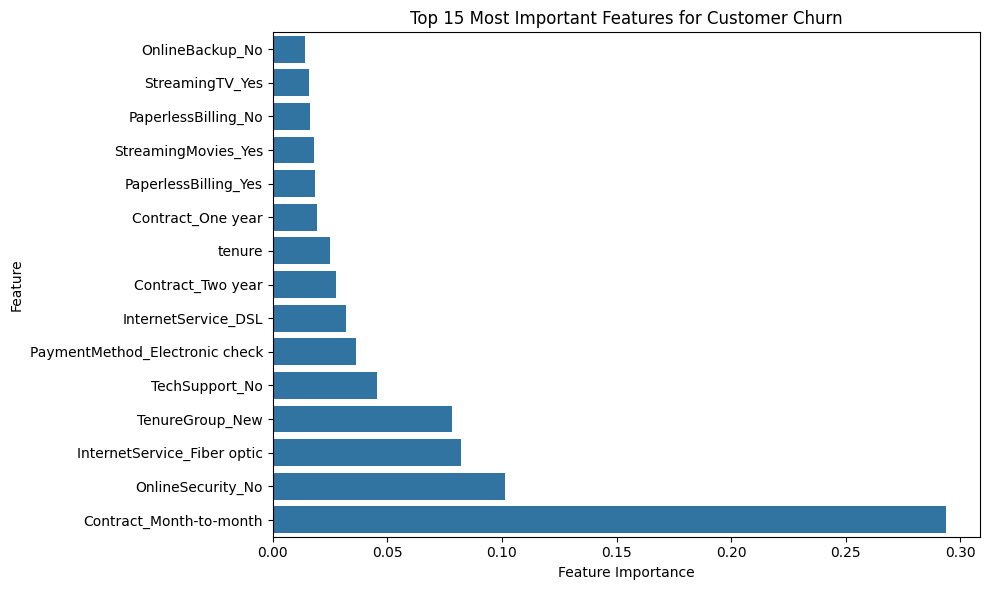

In [101]:
# Get the fitted preprocessor and XGBoost model
preprocessor_fitted = best_xgb_model.named_steps["preprocessor"]
xgb_classifier = best_xgb_model.named_steps["model"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance values
importances = xgb_classifier.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Clean feature names
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Select top 15 features
importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
    .sort_values("Importance")
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Top 15 Most Important Features for Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Step 18: ROC and Precision-Recall Curves

Visualize model performance across different classification thresholds.

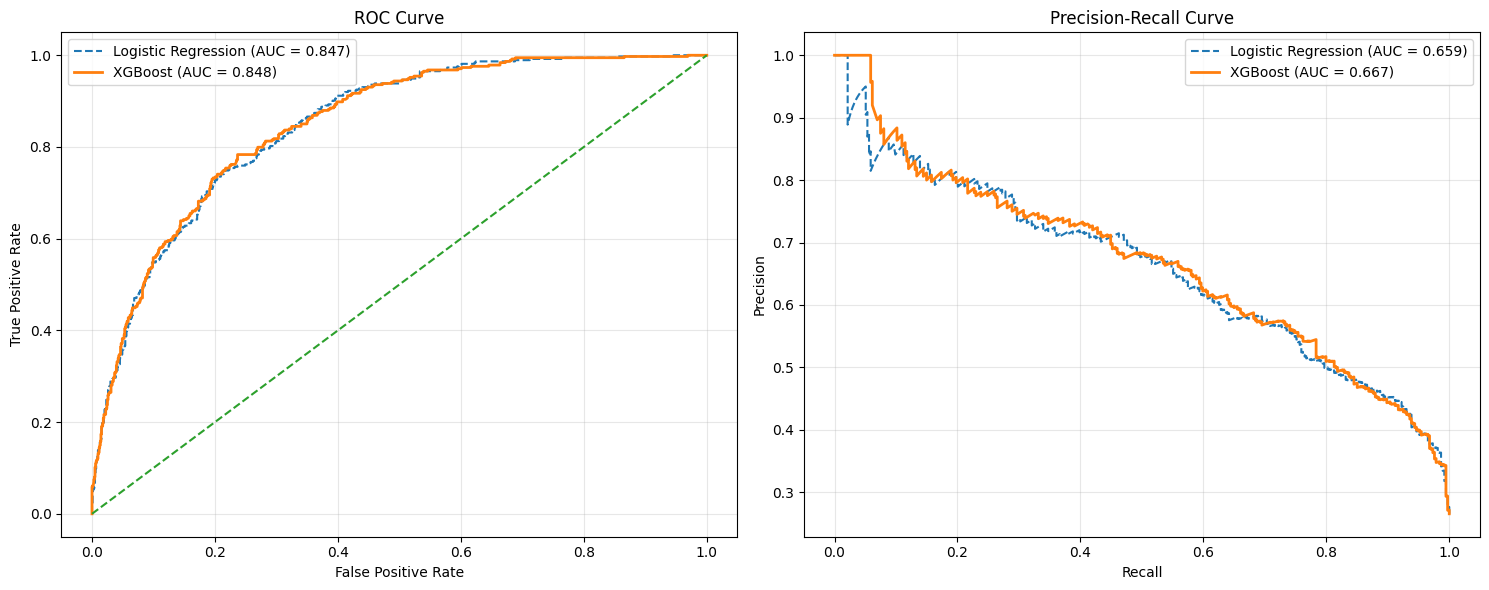

In [102]:
# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, final_prob)

# Precision-Recall curves
precision_log, recall_log, _ = precision_recall_curve(y_test, log_prob)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, final_prob)

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax1.plot(
    fpr_log,
    tpr_log,
    linestyle="--",
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, log_prob):.3f})"
)

ax1.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, final_prob):.3f})"
)

ax1.plot([0, 1], [0, 1], linestyle="--")

ax1.set_title("ROC Curve")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()
ax1.grid(alpha=0.3)

# Precision-Recall Curve
ax2.plot(
    recall_log,
    precision_log,
    linestyle="--",
    label=f"Logistic Regression (AUC = {auc(recall_log, precision_log):.3f})"
)

ax2.plot(
    recall_xgb,
    precision_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {auc(recall_xgb, precision_xgb):.3f})"
)

ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 19: Handle Class Imbalance

Train XGBoost with `scale_pos_weight` to give greater importance to churn customers.

In [103]:
# Calculate class imbalance ratio
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Non-churn customers:", negative)
print("Churn customers:", positive)
print("Scale Pos Weight:", scale_pos_weight)

# Train class-weighted XGBoost
xgb_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_balanced.fit(X_train, y_train)

balanced_pred = xgb_balanced.predict(X_test)
balanced_prob = xgb_balanced.predict_proba(X_test)[:, 1]

print("\nClass-Weighted XGBoost")
print("----------------------")
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1:", f1_score(y_test, balanced_pred))
print("ROC AUC:", roc_auc_score(y_test, balanced_prob))

Non-churn customers: 4139
Churn customers: 1495
Scale Pos Weight: 2.768561872909699

Class-Weighted XGBoost
----------------------
Accuracy: 0.7544357700496807
Precision: 0.5251798561151079
Recall: 0.7807486631016043
F1: 0.6279569892473118
ROC AUC: 0.8441680229404015


## Step 20: Classification Threshold Tuning

Test different probability thresholds to find a better balance between precision and recall.

In [104]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    threshold_pred = (final_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1": f1_score(y_test, threshold_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.20,0.469027,0.850267,0.604563
1,0.25,0.502479,0.812834,0.621042
2,0.30,0.539595,0.783422,0.639040
3,0.35,0.572327,0.729947,0.641598
4,0.40,0.592771,0.657754,0.623574
5,0.45,0.642442,0.590909,0.615599
6,0.50,0.680851,0.513369,0.585366
7,0.55,0.711207,0.441176,0.544554
8,0.60,0.737143,0.344920,0.469945
9,0.65,0.760563,0.288770,0.418605


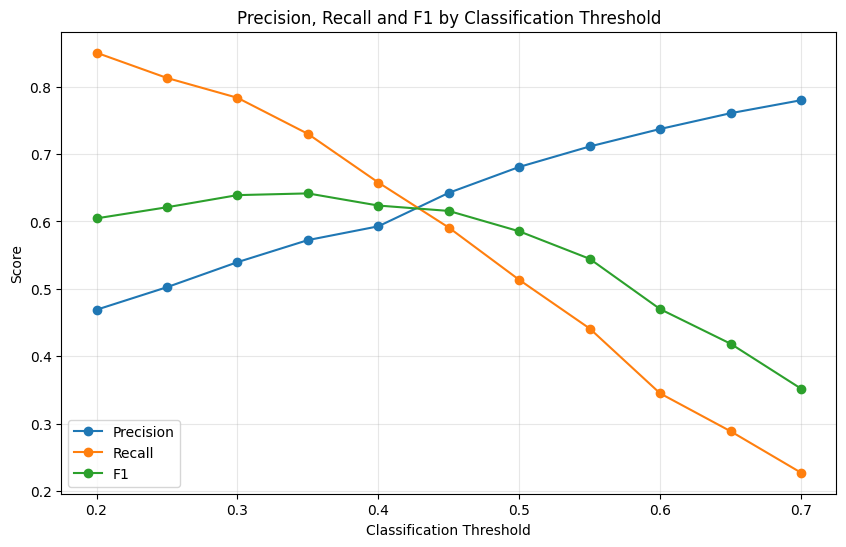

In [105]:
# Plot the results

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Step 21: Final Model Comparison

Compare the baseline, tuned, and class-weighted XGBoost models using the main evaluation metrics.

In [106]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Original XGBoost",
        "Class-Weighted XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, final_pred),
        accuracy_score(y_test, balanced_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, final_pred),
        precision_score(y_test, balanced_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, final_pred),
        recall_score(y_test, balanced_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, final_pred),
        f1_score(y_test, balanced_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, final_prob),
        roc_auc_score(y_test, balanced_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804116,0.666667,0.524064,0.586826,0.846640
1,Original XGBoost,0.806955,0.680851,0.513369,0.585366,0.848115
2,Class-Weighted XGBoost,0.754436,0.525180,0.780749,0.627957,0.844168


## Step 22: Save the Final Model

Save the selected XGBoost pipeline so it can be reused for future predictions.

In [107]:
# Save the original tuned XGBoost model
joblib.dump(
    best_xgb_model,
    "churn_xgboost_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


## Step 23: Real-Time Customer Prediction

Simulate a real-world prediction by providing a new customer's information to the trained XGBoost pipeline.

In [108]:
def predict_customer(custom_input):
    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([custom_input])

    # Create engineered features
    input_df["ValueRatio"] = (
        input_df["TotalCharges"] /
        (input_df["tenure"] + 1)
    )

    input_df["TenureGroup"] = pd.cut(
        input_df["tenure"],
        bins=[0, 12, 24, 48, 72],
        labels=["New", "Short", "Medium", "Long"]
    )

    # Make prediction
    prediction = best_xgb_model.predict(input_df)[0]
    probability = best_xgb_model.predict_proba(input_df)[0][1]

    print("Customer Churn Prediction")
    print("-------------------------")
    print("Prediction:", "CHURN" if prediction == 1 else "NO CHURN")
    print(f"Churn Probability: {probability:.2%}")


# Example customer
new_customer = {
    "gender": "Male",
    "SeniorCitizen": 1,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 286.50
}

predict_customer(new_customer)

Customer Churn Prediction
-------------------------
Prediction: CHURN
Churn Probability: 85.14%


## Step 24: Conclusion

This project developed an end-to-end customer churn prediction pipeline using XGBoost. Model performance was evaluated using multiple metrics, including ROC-AUC, precision, recall, and F1-score. Feature importance and threshold analysis were also used to improve model interpretation and churn detection.